In [14]:
import os
pythonpath = os.getenv("PYTHONPATH")
cwd = os.getcwd()
print(f'CWD={cwd}')
pythonpath = f'{pythonpath}:{cwd}'
print(f'PYTHONPATH={pythonpath}')
os.environ["PYTHONPATH"] = pythonpath

CWD=/home/swhors/jupyter-workspace/finance
PYTHONPATH=/home/swhors/jupyter-workspace/venv/lib/python3.11/site-packages:/home/swhors/jupyter-workspace/finance:/home/swhors/jupyter-workspace/finance


In [26]:
from service.market_value import get_market_value_from_db
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.font_manager as fm


def check_font():
    """ check os fonts """
    fm.fontManager.ttflist # 사용 가능한 폰트 확인
    for f in fm.fontManager.ttflist:
        print(f.name)


def change_font():
    """ chnage matplotlib fonts """
    matplotlib.rcParams['font.family'] = 'NanumGothic'
    matplotlib.rcParams['font.size'] = 8 # 글자 크기
    matplotlib.rcParams['axes.unicode_minus'] = False 


change_font()
print(f'PYTHONPATH={os.getenv("PYTHONPATH")}')

PYTHONPATH=/home/swhors/jupyter-workspace/venv/lib/python3.11/site-packages:/home/swhors/jupyter-workspace/finance:/home/swhors/jupyter-workspace/finance


In [27]:
def send_metric(from_date, to_date, code, name, market, debug=False):
    """wrap function for service.graphite_svc.send_metric"""
    from service.graphite_svc import send_metric as graphite_send_metric
    datas = get_market_value_from_db(from_date=from_date, to_date=to_date, code=code, name=name)
    print(f'{name}, {code}, {market} --- start')
    for data in datas:
        graphite_send_metric(market_value=data, market=market, debug=debug)
    print(f'{name}, {code}, {market} --- end')


def draw_plot(from_date, to_date, code, name, market):
    """ draw plot """
    datas = get_market_value_from_db(from_date=from_date, to_date=to_date, code=code, name=name)
    close = [d.close for d in datas]
    # volume = [d.volume/1000000000 for d in datas]
    updated = [d.updated for d in datas]
    plt.plot(updated, close, label="value")
    # plt.plot(updated, volume, label="volume")
    if name is not None:
        title = market + " - " + name + " - " + code
    else:
        title = market + " - " + code
    plt.xlabel("date")
    plt.title(title)
    plt.show()

In [28]:
# start_date = "2023-01-01"
start_date = "2023-01-01"
end_date = "2025-01-04"
reqs = [
    (start_date, end_date, "AAPL", None, "NASDAQ"),
    (start_date, end_date, "NVDA", None, "NASDAQ"),
    (start_date, end_date, "ARM", None, "NASDAQ"),
    (start_date, end_date, "AMZN", None, "NASDAQ"),
    (start_date, end_date, "MSFT", None, "NASDAQ"),
    (start_date, end_date, "DIS", None, "NASDAQ"),
    (start_date, end_date, "TSLA", None, "NASDAQ"),
    (start_date, end_date, "005930", "삼성전자", "KOSPI"),
    (start_date, end_date, "035720", "카카오", "KOSPI"),
    (start_date, end_date, "139050", "BF랩스", "KOSPI"),
    (start_date, end_date, "000660", "SK하이닉스", "KOSPI"),
    (start_date, end_date, "105560", "KB금융", "KOSPI"),
    (start_date, end_date, "006400", "삼성SDI", "KOSPI"),
    (start_date, end_date, "000270", "기아", "KOSPI")
]

2023-01-01, 2025-01-04, AAPL, None
query=select * from market_value where code="AAPL" and updated>="2023-01-01" and updated<="2025-01-04" order by updated asc


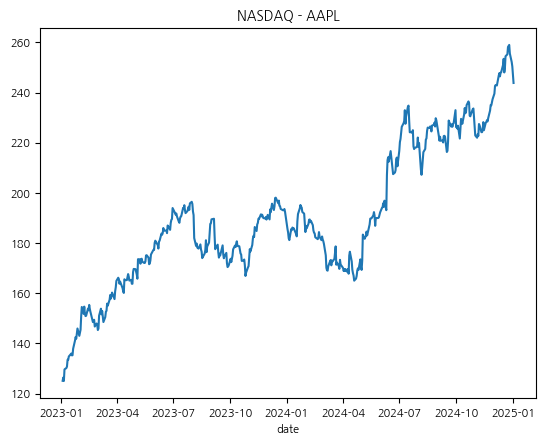

2023-01-01, 2025-01-04, NVDA, None
query=select * from market_value where code="NVDA" and updated>="2023-01-01" and updated<="2025-01-04" order by updated asc


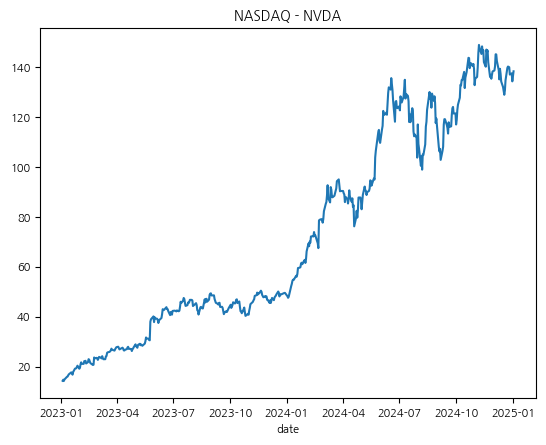

2023-01-01, 2025-01-04, ARM, None
query=select * from market_value where code="ARM" and updated>="2023-01-01" and updated<="2025-01-04" order by updated asc


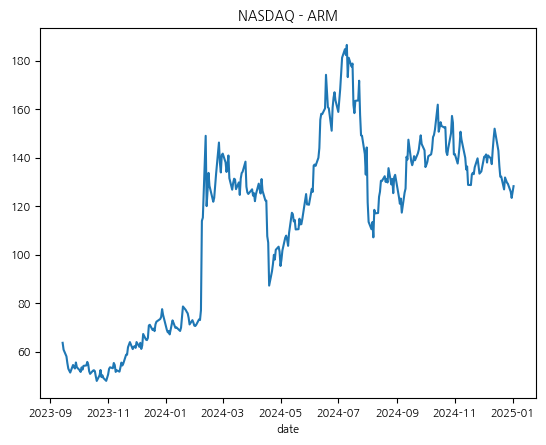

2023-01-01, 2025-01-04, AMZN, None
query=select * from market_value where code="AMZN" and updated>="2023-01-01" and updated<="2025-01-04" order by updated asc


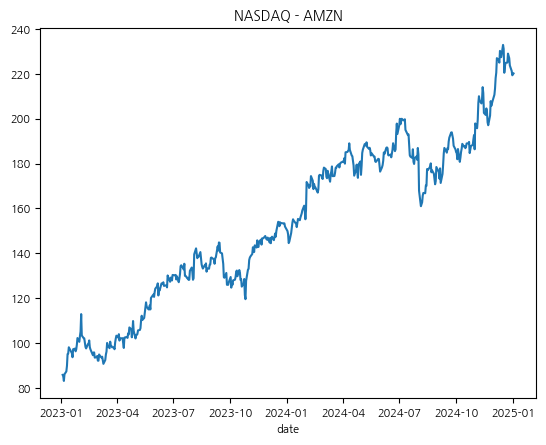

2023-01-01, 2025-01-04, MSFT, None
query=select * from market_value where code="MSFT" and updated>="2023-01-01" and updated<="2025-01-04" order by updated asc


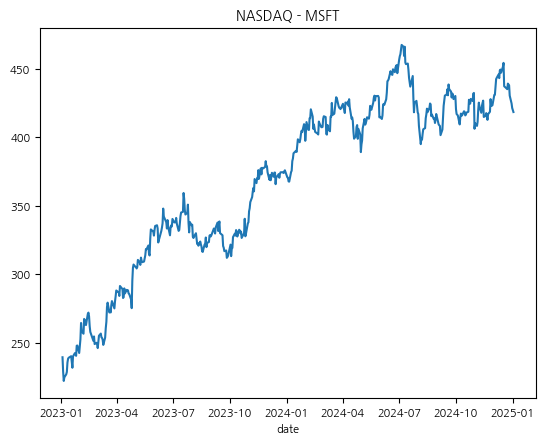

2023-01-01, 2025-01-04, DIS, None
query=select * from market_value where code="DIS" and updated>="2023-01-01" and updated<="2025-01-04" order by updated asc


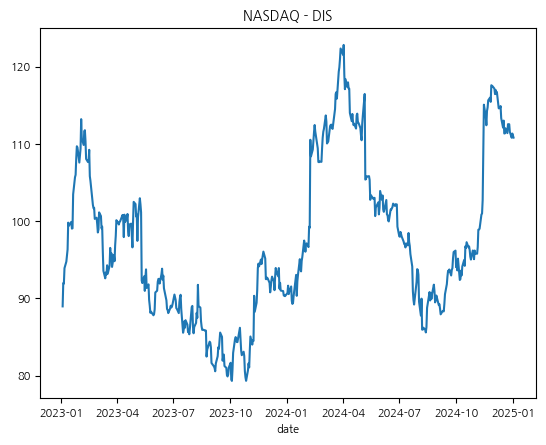

2023-01-01, 2025-01-04, TSLA, None
query=select * from market_value where code="TSLA" and updated>="2023-01-01" and updated<="2025-01-04" order by updated asc


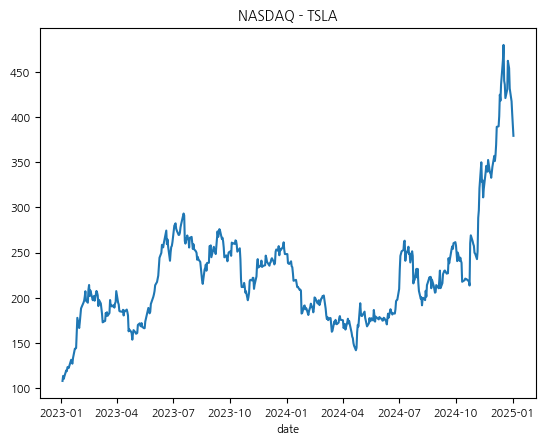

2023-01-01, 2025-01-04, 005930, 삼성전자
query=select * from market_value where code="005930" and updated>="2023-01-01" and updated<="2025-01-04" order by updated asc


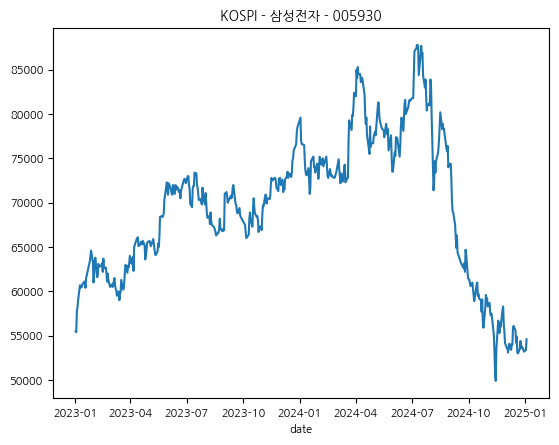

2023-01-01, 2025-01-04, 035720, 카카오
query=select * from market_value where code="035720" and updated>="2023-01-01" and updated<="2025-01-04" order by updated asc


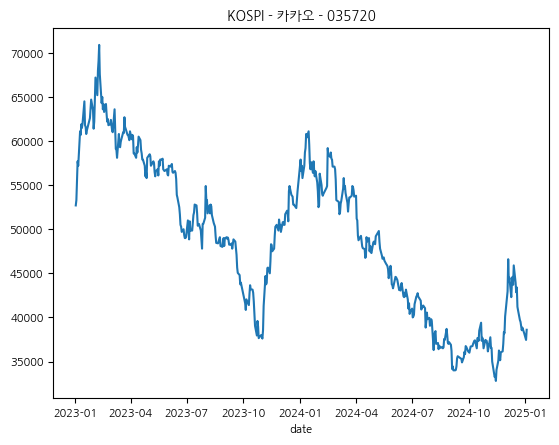

2023-01-01, 2025-01-04, 139050, BF랩스
query=select * from market_value where code="139050" and updated>="2023-01-01" and updated<="2025-01-04" order by updated asc


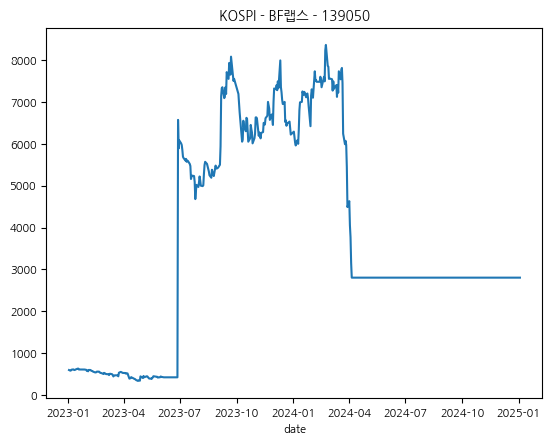

2023-01-01, 2025-01-04, 000660, SK하이닉스
query=select * from market_value where code="000660" and updated>="2023-01-01" and updated<="2025-01-04" order by updated asc


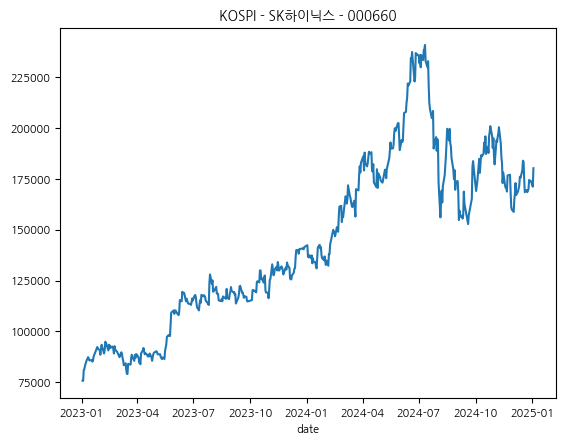

2023-01-01, 2025-01-04, 105560, KB금융
query=select * from market_value where code="105560" and updated>="2023-01-01" and updated<="2025-01-04" order by updated asc


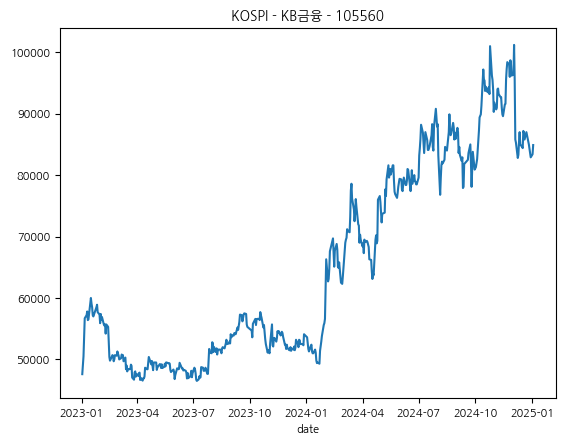

2023-01-01, 2025-01-04, 006400, 삼성SDI
query=select * from market_value where code="006400" and updated>="2023-01-01" and updated<="2025-01-04" order by updated asc


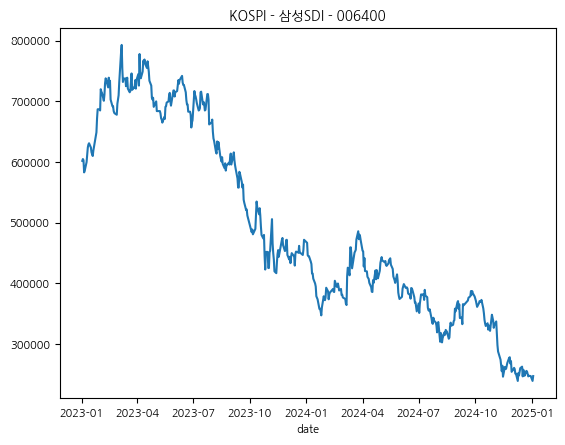

2023-01-01, 2025-01-04, 000270, 기아
query=select * from market_value where code="000270" and updated>="2023-01-01" and updated<="2025-01-04" order by updated asc


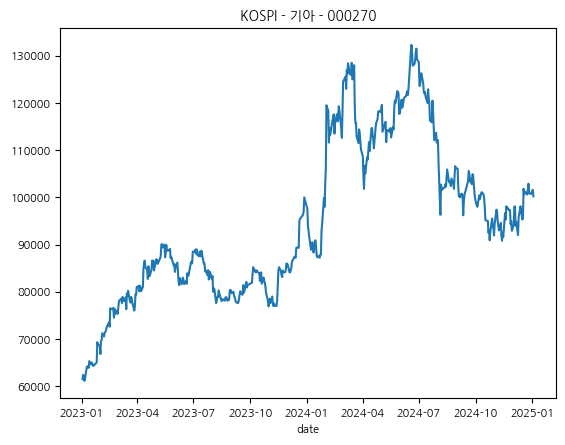

In [29]:
for req in reqs:
    print(f'{req[0]}, {req[1]}, {req[2]}, {req[3]}')
    draw_plot(from_date=req[0], to_date=req[1], code=req[2], name=req[3], market=req[4])
    # send_metric(from_date=req[0], to_date=req[1], code=req[2], name=req[3], market=req[4], debug=True)